<a href="https://colab.research.google.com/github/bala1592max/Bala_TQM_AI/blob/main/Energy_Efficiency_dataset__Regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load Energy Efficiency Dataset from UCI datasets**

In [24]:
import random
import numpy as np
import os

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# If using TensorFlow/Keras
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
except ImportError:
    pass

# If using PyTorch (optional)
try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

### **1. Energy Efficiency Dataset**
Goal: Predict energy efficiency of buildings: heating and cooling loads.

* Source: UCI Energy Efficiency Data Set

Target Variables:

* **Y1: Heating load** -- Considering this for demonstration

* Y2: Cooling load

Features (all numeric):

* Relative Compactness

* Surface Area

* Wall Area

* Roof Area

* Overall Height

* Orientation

* Glazing Area

* Glazing Area Distribution

# **Import Libraries**





In [25]:
import ssl
import urllib.request
import io
import pandas as pd

import zipfile

# Create an unverified SSL context explicitly
unverified_context = ssl._create_unverified_context()

# Updated URL for the dataset (zip file)
url = "https://archive.ics.uci.edu/static/public/242/energy+efficiency.zip"
excel_filename_in_zip = "ENB2012_data.xlsx" # The name of the Excel file inside the zip

# Use urllib.request.urlopen with the explicit unverified context
try:
    with urllib.request.urlopen(url, context=unverified_context) as response:
        # Read the content into a BytesIO object
        zip_data = io.BytesIO(response.read())

    # Open the zip file from the BytesIO object
    with zipfile.ZipFile(zip_data, 'r') as zf:
        # Read the specific Excel file from the zip archive
        with zf.open(excel_filename_in_zip) as excel_file:
            df = pd.read_excel(excel_file)

except Exception as e:
    print(f"Error downloading, extracting, or reading excel: {e}")
    raise

### **Target1 Variable**

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [27]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [40]:
# Rename columns for easier access
df.columns = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
              'Overall_Height', 'Orientation', 'Glazing_Area',
              'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']

# Input features and target (we use 'Heating_Load')
X = df.iloc[:, 0:8]
y = df['Heating_Load']
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(" Dataset Summary:")
print(f"- Total samples: {len(df)}")
print(f"- Input features: {list(X.columns)}")
print(f"- Target variable: Heating_Load")
print(f"- Train samples: {len(X_train)}")
print(f"- Validation samples: {len(X_val)}")
print(f"- Test samples: {len(X_test)}\n")

 Dataset Summary:
- Total samples: 768
- Input features: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']
- Target variable: Heating_Load
- Train samples: 521
- Validation samples: 131
- Test samples: 116



### **Helper Function**

In [30]:
def evaluate_model(model, X, y, name="Model"):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    rmse_percent = (rmse / np.mean(y)) * 100

    # Calculate R-squared
    from sklearn.metrics import r2_score
    r2 = r2_score(y, y_pred)

    # Calculate Adjusted R-squared
    n = len(y)
    p = X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"{name:<25} | RMSE: {rmse:.3f} | R2: {r2:.4f} | Adj R2: {adj_r2:.4f}")
    return rmse, r2, y_pred

## **Linear Regression**

## **On Training Set**

 Linear Regression on Training Set:
Linear Regression         | RMSE: 3.016 | R2: 0.9118 | Adj R2: 0.9104


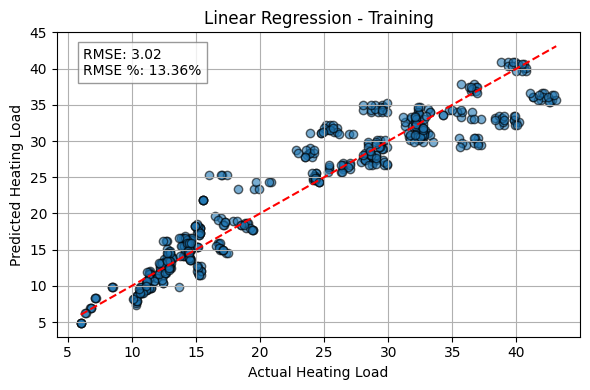

In [31]:
print(" Linear Regression on Training Set:")
lin_model = make_pipeline(StandardScaler(), LinearRegression())
lin_model.fit(X_train, y_train)
rmse_lin, r2_lin, y_pred_lin = evaluate_model(lin_model, X_train, y_train, "Linear Regression")
plot_scatter(y_train, y_pred_lin, "Linear Regression - Training")

## **On Validation Set**

 Linear Regression on Validation Set:
Linear Regression         | RMSE: 2.346 | R2: 0.9400 | Adj R2: 0.9361


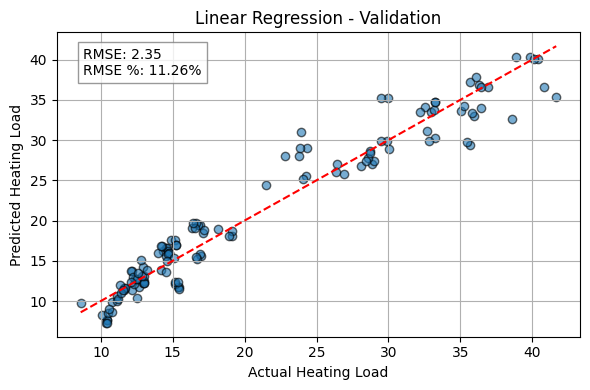

In [32]:
print(" Linear Regression on Validation Set:")
rmse_lin_val, r2_lin_val, y_pred_lin_val = evaluate_model(lin_model, X_val, y_val, "Linear Regression")
plot_scatter(y_val, y_pred_lin_val, "Linear Regression - Validation")

## **Test Set**

 Linear Regression on Test Set:
Linear Regression         | RMSE: 3.131 | R2: 0.9052 | Adj R2: 0.8981


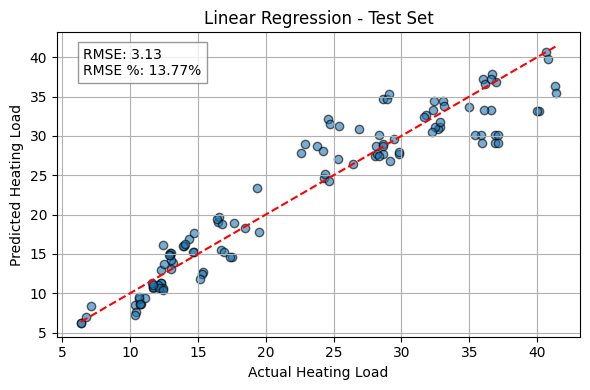

In [33]:
print(" Linear Regression on Test Set:")
rmse_lin_test, r2_lin_test, y_pred_lin_test = evaluate_model(lin_model, X_test, y_test, "Linear Regression")
plot_scatter(y_test, y_pred_lin_test, "Linear Regression - Test Set")

## **Polynomial Regression (Degrees 2-6)**

## **On Training Set**

In [34]:
# 2️ Polynomial Regression (degrees 2 to 7)
results = []
for degree in range(2, 7):
    model = make_pipeline(StandardScaler(), PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    rmse, r2, y_pred = evaluate_model(model, X_train, y_train, name=f"Polynomial Degree {degree} (Train Set)")
    results.append((degree, rmse, r2, model))

Polynomial Degree 2 (Train Set) | RMSE: 0.714 | R2: 0.9951 | Adj R2: 0.9950
Polynomial Degree 3 (Train Set) | RMSE: 0.417 | R2: 0.9983 | Adj R2: 0.9983
Polynomial Degree 4 (Train Set) | RMSE: 0.305 | R2: 0.9991 | Adj R2: 0.9991
Polynomial Degree 5 (Train Set) | RMSE: 0.206 | R2: 0.9996 | Adj R2: 0.9996
Polynomial Degree 6 (Train Set) | RMSE: 0.097 | R2: 0.9999 | Adj R2: 0.9999


In [35]:
# Select best model (based on RMSE)
best_degree, best_rmse, best_r2, best_model = min(results, key=lambda x: x[1])
print(f"\n Best degree on Training set: {best_degree} with RMSE: {best_rmse:.3f}, R²: {best_r2:.3f}")


 Best degree on Training set: 6 with RMSE: 0.097, R²: 1.000



 Polynomial Regression on Training Set:
Polynomial Degree 2       | RMSE: 0.714 | R2: 0.9951 | Adj R2: 0.9950


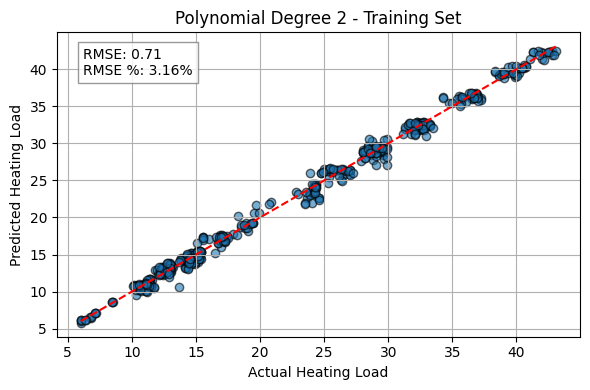

Polynomial Degree 3       | RMSE: 0.417 | R2: 0.9983 | Adj R2: 0.9983


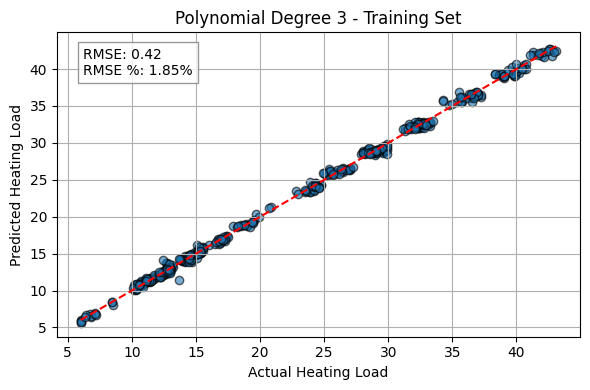

Polynomial Degree 4       | RMSE: 0.305 | R2: 0.9991 | Adj R2: 0.9991


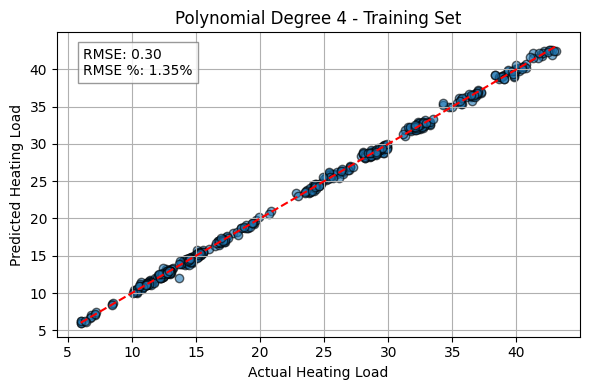

Polynomial Degree 5       | RMSE: 0.206 | R2: 0.9996 | Adj R2: 0.9996


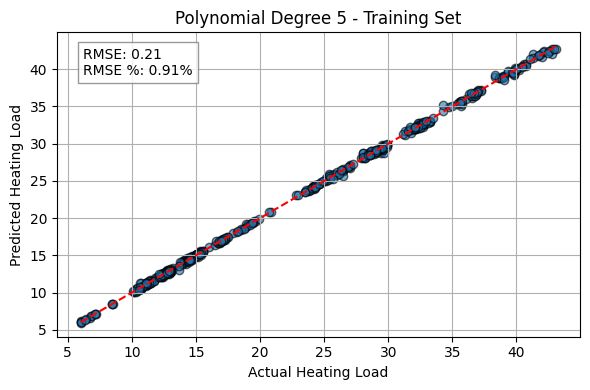

Polynomial Degree 6       | RMSE: 0.097 | R2: 0.9999 | Adj R2: 0.9999


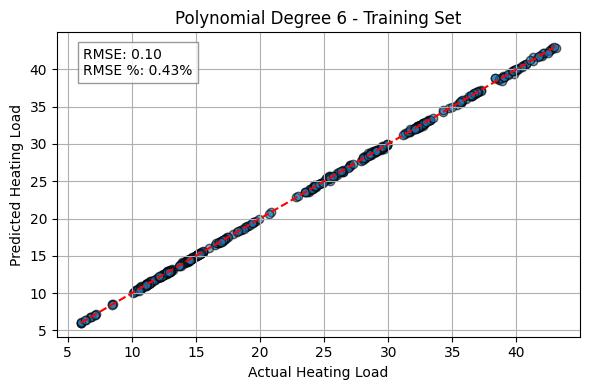


 Polynomial Regression Performance Summary:
 Degree  RMSE (Train)  RMSE(%) (Train)
      2         0.714            0.995
      3         0.417            0.998
      4         0.305            0.999
      5         0.206            1.000
      6         0.097            1.000


In [36]:
results_tr = []

print("\n Polynomial Regression on Training Set:")

for degree in range(2, 7):
    poly_model = make_pipeline(StandardScaler(),
                               PolynomialFeatures(degree=degree),
                               LinearRegression())
    poly_model.fit(X_train, y_train)
    rmse, r2, y_pred = evaluate_model(poly_model, X_train, y_train, f"Polynomial Degree {degree}")
    plot_scatter(y_train, y_pred, f"Polynomial Degree {degree} - Training Set")

    results_tr.append({
        'Degree': degree,
        'RMSE (Train)': round(rmse, 3),
        'RMSE(%) (Train)': round(r2, 3)
    })

    if r2 > best_r2:
        best_r2 = r2
        best_model = poly_model
        best_deg = degree

# Display table of results
results_df = pd.DataFrame(results_tr)
print("\n Polynomial Regression Performance Summary:")
print(results_df.to_string(index=False))

## **On Validation Set**


 Polynomial Regression on Validation Set:
Polynomial Degree 2       | RMSE: 0.714 | R2: 0.9944 | Adj R2: 0.9941


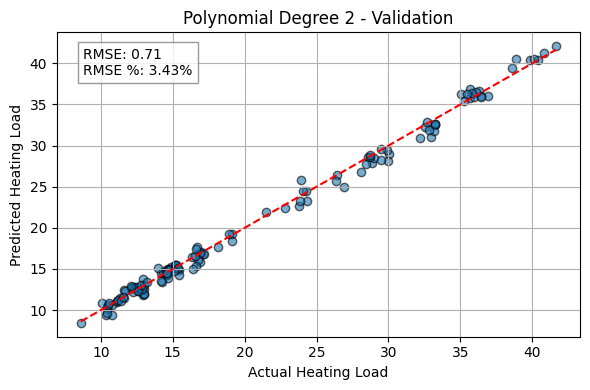

Polynomial Degree 3       | RMSE: 0.438 | R2: 0.9979 | Adj R2: 0.9978


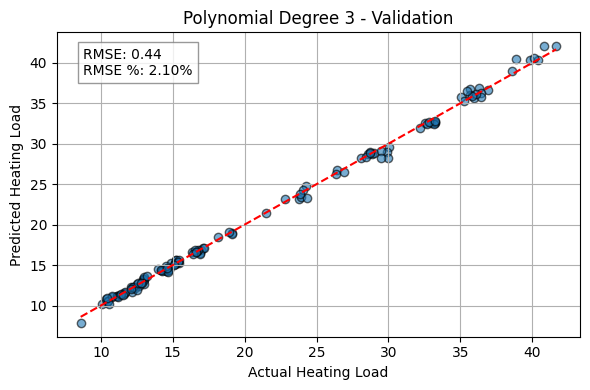

Polynomial Degree 4       | RMSE: 0.472 | R2: 0.9976 | Adj R2: 0.9974


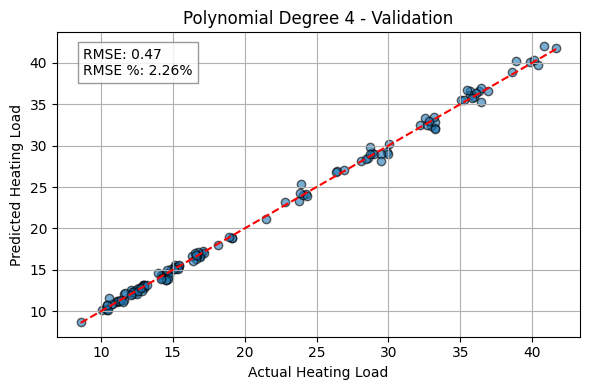

Polynomial Degree 5       | RMSE: 0.602 | R2: 0.9960 | Adj R2: 0.9958


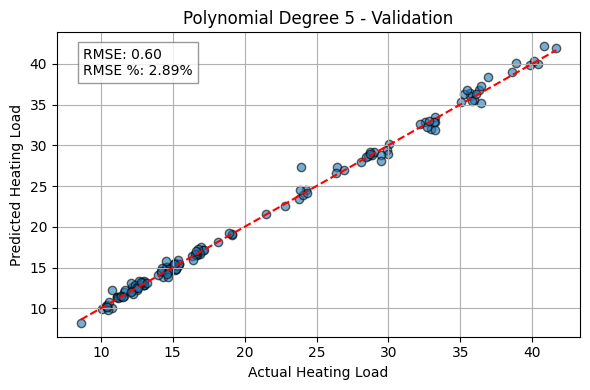

Polynomial Degree 6       | RMSE: 2.896 | R2: 0.9086 | Adj R2: 0.9026


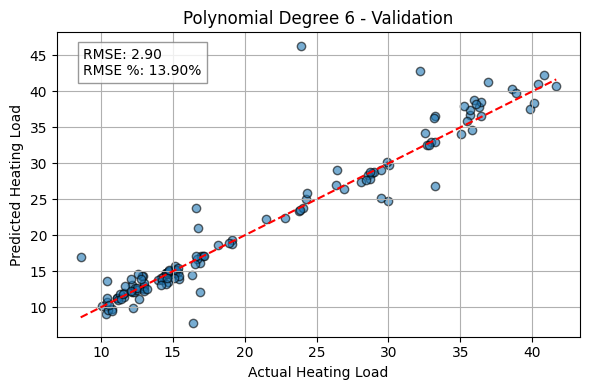


 Polynomial Regression Performance Summary:
 Degree  RMSE (Validation)  RMSE (%) (Validation)
      2              0.714                  0.994
      3              0.438                  0.998
      4              0.472                  0.998
      5              0.602                  0.996
      6              2.896                  0.909


In [37]:
results = []

print("\n Polynomial Regression on Validation Set:")

for degree in range(2, 7):
    poly_model = make_pipeline(StandardScaler(),
                               PolynomialFeatures(degree=degree),
                               LinearRegression())
    poly_model.fit(X_train, y_train)
    rmse, r2, y_pred = evaluate_model(poly_model, X_val, y_val, f"Polynomial Degree {degree}")
    plot_scatter(y_val, y_pred, f"Polynomial Degree {degree} - Validation")

    results.append({
        'Degree': degree,
        'RMSE (Validation)': round(rmse, 3),
        'RMSE (%) (Validation)': round(r2, 3)
    })

    if r2 > best_r2:
        best_r2 = r2
        best_model = poly_model
        best_deg = degree

# Display table of results
results_df = pd.DataFrame(results)
print("\n Polynomial Regression Performance Summary:")
print(results_df.to_string(index=False))


Polynomial Regression Evaluation:
Degree | #Monomials   | Train RMSE | Val RMSE  
--------------------------------------------------
Degree 1 (Train)          | RMSE: 3.016 | R2: 0.9118 | Adj R2: 0.9104
Degree 1 (Val)            | RMSE: 2.346 | R2: 0.9400 | Adj R2: 0.9361
1      | 9            | 3.016      | 2.346     
Degree 2 (Train)          | RMSE: 0.714 | R2: 0.9951 | Adj R2: 0.9950
Degree 2 (Val)            | RMSE: 0.714 | R2: 0.9944 | Adj R2: 0.9941
2      | 45           | 0.714      | 0.714     
Degree 3 (Train)          | RMSE: 0.417 | R2: 0.9983 | Adj R2: 0.9983
Degree 3 (Val)            | RMSE: 0.438 | R2: 0.9979 | Adj R2: 0.9978
3      | 165          | 0.417      | 0.438     
Degree 4 (Train)          | RMSE: 0.305 | R2: 0.9991 | Adj R2: 0.9991
Degree 4 (Val)            | RMSE: 0.472 | R2: 0.9976 | Adj R2: 0.9974
4      | 495          | 0.305      | 0.472     
Degree 5 (Train)          | RMSE: 0.206 | R2: 0.9996 | Adj R2: 0.9996
Degree 5 (Val)            | RMSE: 0.602 | R2

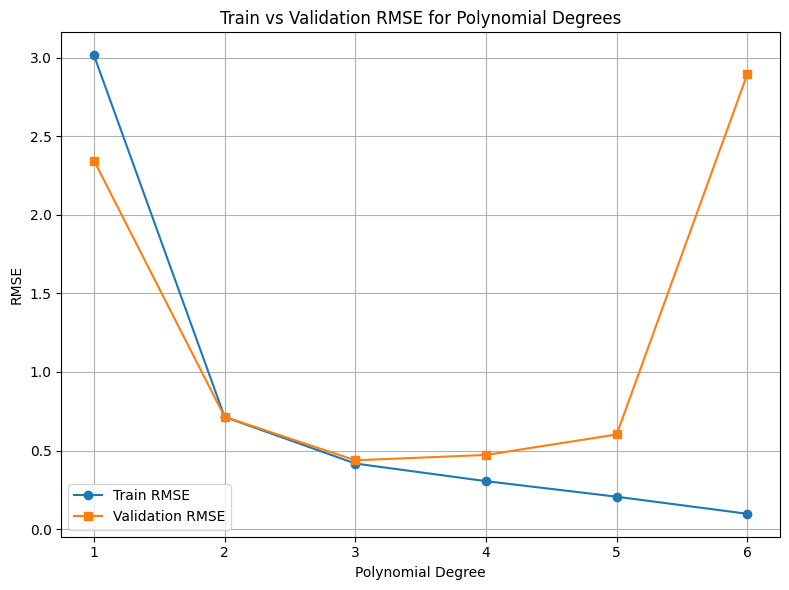


Best Polynomial Degree: 3 with Validation RMSE: 0.438


In [38]:
from math import comb

# Range of degrees to try
start_degree = 1
end_degree = 6

train_rmses = []
val_rmses = []
monomial_counts = []
degrees = list(range(start_degree, end_degree + 1))
best_model = None
best_val_rmse = float("inf")
best_deg = None

print("\nPolynomial Regression Evaluation:")
print(f"{'Degree':<6} | {'#Monomials':<12} | {'Train RMSE':<10} | {'Val RMSE':<10}")
print("-" * 50)

for degree in degrees:
    # Compute number of monomials for given degree and input dim
    n_features = X_train.shape[1]
    num_monomials = comb(n_features + degree, degree)
    monomial_counts.append(num_monomials)

    # Build and train model
    model = make_pipeline(StandardScaler(), PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)

    # Evaluate on train and validation sets
    train_rmse, _, _ = evaluate_model(model, X_train, y_train, name=f"Degree {degree} (Train)")
    val_rmse, _, _ = evaluate_model(model, X_val, y_val, name=f"Degree {degree} (Val)")

    # Store results
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)

    # Print summary for each degree
    print(f"{degree:<6} | {num_monomials:<12} | {train_rmse:<10.3f} | {val_rmse:<10.3f}")

    # Update best model
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_model = model
        best_deg = degree

# Plot RMSEs for all degrees
plt.figure(figsize=(8, 6))
plt.plot(degrees, train_rmses, marker='o', label='Train RMSE')
plt.plot(degrees, val_rmses, marker='s', label='Validation RMSE')
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Train vs Validation RMSE for Polynomial Degrees")
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print best model info
print(f"\nBest Polynomial Degree: {best_deg} with Validation RMSE: {best_val_rmse:.3f}")


### **Final Evaluation on Test Set**


Final Evaluation on Test Set using Best Polynomial Degree: 3
Polynomial Degree 3 - Test Set | RMSE: 0.537 | R2: 0.9972 | Adj R2: 0.9970


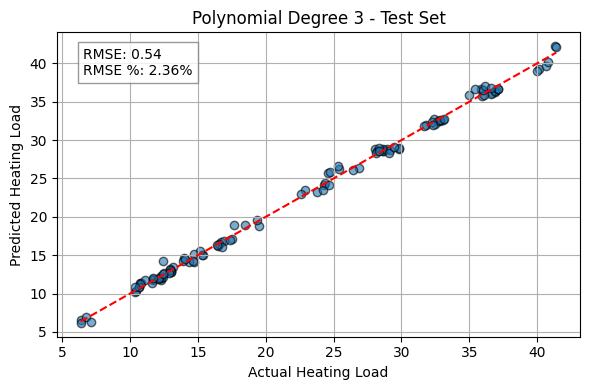

  - RMSE (Test): 0.537
  - RMSE% (relative to mean y): 2.36%


In [39]:
# Evaluate best model on test set
print(f"\nFinal Evaluation on Test Set using Best Polynomial Degree: {best_deg}")
rmse_test, r2_test, y_pred_test = evaluate_model(best_model, X_test, y_test, f"Polynomial Degree {best_deg} - Test Set")
plot_scatter(y_test, y_pred_test, f"Polynomial Degree {best_deg} - Test Set")

rmse_percent = (rmse_test / np.mean(np.abs(y_test))) * 100
print(f"  - RMSE (Test): {round(rmse_test, 3)}")
print(f"  - RMSE% (relative to mean y): {round(rmse_percent, 2)}%")
